In [28]:
import re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks

In [29]:
df_3_9GHz_25dBm_250605_204447 = pd.read_csv('Data/TWPA_on_S21_3.00-9.00GHz_-25.0dBm_20250605_204447.csv')
df_3_9GHz_25dBm_250605_205417 = pd.read_csv('Data/TWPA_on_S21_3.00-9.00GHz_-25.0dBm_20250605_205417.csv')
df_3_9GHz_25dBm_250605_205529 = pd.read_csv('Data/TWPA_on_S21_3.00-9.00GHz_-25.0dBm_20250605_205529.csv')
df_3_9GHz_35dBm_250604_181840 = pd.read_csv('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250604_181840.csv')
df_3_9GHz_35dBm_250604_192329 = pd.read_csv('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250604_192329.csv')
df_3_9GHz_35dBm_250604_192358 = pd.read_csv('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250604_192358.csv')
df_3_9GHz_35dBm_250605_170409 = pd.read_csv('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250605_170409.csv')
df_3_9GHz_35dBm_250605_191549 = pd.read_csv('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250605_191549.csv')
df_3_9GHz_35dBm_250605_192903 = pd.read_csv('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250605_192903.csv')
df_3_9GHz_35dBm_250605_194422 = pd.read_csv('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250605_194422.csv')
df_3_9GHz_35dBm_250605_200136 = pd.read_csv('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250605_200136.csv')
df_3_9GHz_35dBm_250605_201637 = pd.read_csv('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250605_201637.csv')
df_3_9GHz_35dBm_250605_204435 = pd.read_csv('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250605_204435.csv')


sim_f0_kin_res = np.array([5.566,4.680,4.645,4.434,4.162,6.206])
theo_f0_kin_res = np.array([8.51077059,7.49291156,8.20177958,
                            7.14371248,7.8479671,8.8257005])

In [30]:
FNAME_RE = re.compile(r'_(-?[\d.]+)dBm_(\d{8}_\d{6})\.csv$')

# (filename, indices of false peaks to drop -- based on inspection)
runs = [
    ('Data/TWPA_on_S21_3.00-9.00GHz_-25.0dBm_20250605_204447.csv',
     [0, 1, 3, 5, 17, 18, 20, 21, 22, 25, 27, 28]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-25.0dBm_20250605_205417.csv',
     [0, 2, 4, 15, 16, 17, 19, 21, 23, 24, 25]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-25.0dBm_20250605_205529.csv',
     [0, 1, 3, 5, 17, 18, 21, 23, 24, 25, 26, 28, 29]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250604_181840.csv',
     [0, 1, 2, 3, 4, 6, 7, 14, 17, 19, 20, 24, 25, 28, 29]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250604_192329.csv',
     [0, 1, 3, 4, 5, 7, 8, 18, 19, 20, 22, 23, 25, 26, 27]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250604_192358.csv',
     [0, 2, 3, 4, 5, 7, 15, 16, 21, 22, 23, 26, 27, 29, 31, 32, 34]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250605_170409.csv',
     [0, 1, 3, 4, 6, 18, 19, 20, 22, 23, 24, 26, 28, 30]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250605_191549.csv',
     [0, 1, 3, 4, 5, 7, 19, 20, 21, 23, 24, 27, 28, 30]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250605_192903.csv',
     [0, 1, 3, 4, 5, 7, 9, 20, 21, 22, 24, 25, 26, 28, 29, 31]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250605_194422.csv',
     [0, 1, 3, 4, 6, 18, 19, 20, 22, 23, 25, 26, 27, 29]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250605_200136.csv',
     [0, 1, 2, 3, 4, 5, 7, 13, 20, 21, 22, 23, 25, 26, 27, 30, 32, 33]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250605_201637.csv',
     [0, 1, 2, 3, 4, 5, 7, 19, 20, 21, 23, 24, 25, 27, 28, 29, 31]),
    ('Data/TWPA_on_S21_3.00-9.00GHz_-35.0dBm_20250605_204435.csv',
     [0, 1, 3, 4, 5, 7, 17, 19, 20, 21, 22, 24, 25, 26, 28, 29, 32]),
]

dfs, peaks, columns = {}, {}, {}

for fname, remove_idx in runs:
    power_str, timestamp = FNAME_RE.search(fname).groups()
    label = f'{abs(float(power_str)):.1f}dBm_{timestamp}'

    df = pd.read_csv(fname)
    inverted = -df['Magnitude (dB)']
    pk, _ = find_peaks(inverted, height=55, distance=135)

    dfs[label]     = df
    peaks[label]   = np.delete(pk, remove_idx)
    columns[label] = f'{label} (GHz)'

# Each Series is reindexed 0..n-1 before combining so rows line up by
# "peak order" rather than by original CSV row number (the original
# code combined on the raw row index, which silently shuffles rows
# whenever two runs' peaks land on different row numbers).
saved_df = pd.DataFrame({
    columns[label]: dfs[label]['Frequency (GHz)'].iloc[idx].reset_index(drop=True)
    for label, idx in peaks.items()
})

saved_df.to_csv('final.csv', index=True)
saved_df.head(40)

,25.0dBm_20250605_204447 (GHz),25.0dBm_20250605_205417 (GHz),25.0dBm_20250605_205529 (GHz),35.0dBm_20250604_181840 (GHz),35.0dBm_20250604_192329 (GHz),35.0dBm_20250604_192358 (GHz),35.0dBm_20250605_170409 (GHz),35.0dBm_20250605_191549 (GHz),35.0dBm_20250605_192903 (GHz),35.0dBm_20250605_194422 (GHz),35.0dBm_20250605_200136 (GHz),35.0dBm_20250605_201637 (GHz),35.0dBm_20250605_204435 (GHz)
0,3.28800,3.28800,3.28800,3.86925,3.28800,3.21675,3.23775,3.28725,3.28950,3.28800,3.90300,3.90450,3.28950
1,3.90150,3.90150,3.90225,4.44900,3.87600,3.90525,3.90375,3.90225,3.90450,3.81375,4.18425,4.15725,3.90075
2,4.18350,4.18425,4.18425,4.80300,4.44825,4.16025,4.13550,4.15425,4.18425,4.18425,4.44825,4.44900,4.15650
3,4.44825,4.44825,4.44825,4.91850,4.80525,4.44900,4.44900,4.44900,4.44825,4.44825,4.80300,4.80375,4.44900
4,4.80300,4.80375,4.80300,5.27400,4.91775,4.80225,4.80225,4.80450,4.80225,4.80375,4.91775,4.91775,4.80225
5,4.91775,4.91775,4.91775,5.61300,5.28225,4.91775,4.91775,4.91775,4.91775,4.91775,5.27925,5.27475,4.91775
6,5.27625,5.27700,5.27850,5.79600,5.61525,5.28000,5.27550,5.28300,5.28225,5.27850,5.61750,5.61525,5.27850
7,5.61225,5.61300,5.61375,6.71400,5.80050,5.61375,5.61600,5.61150,5.60925,5.61375,5.80575,5.80425,5.61375
8,5.80125,5.79900,5.79900,6.82650,6.71100,5.79675,5.80425,5.80050,5.79975,5.80500,6.71850,6.71100,5.80800
9,6.71475,6.71625,6.71850,7.08225,6.82650,6.71700,6.71775,6.72075,6.71775,6.71700,6.82725,6.82650,6.71550


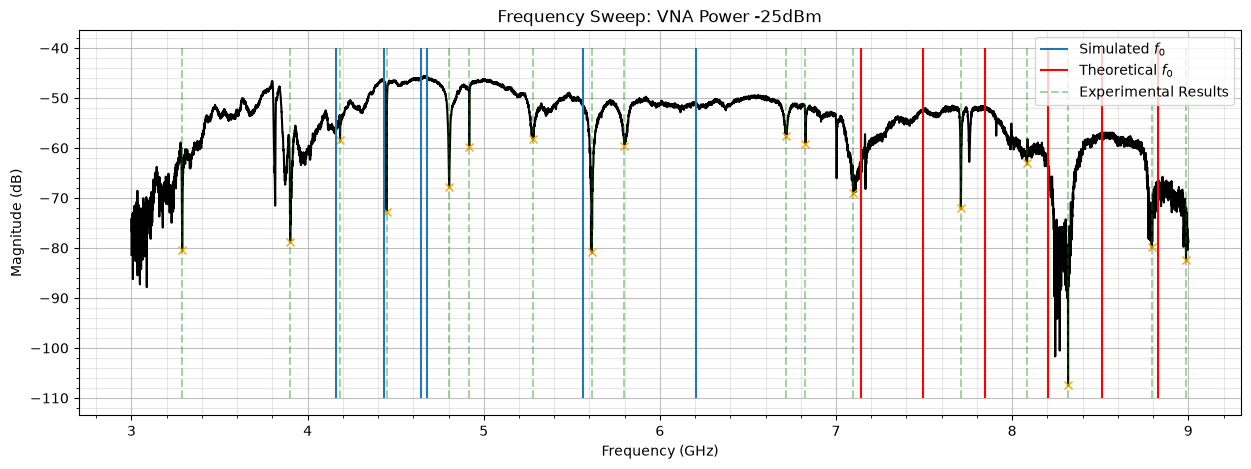

In [31]:
plt.figure(figsize=(15,5))
plt.title('Frequency Sweep: VNA Power -25dBm')
plt.ylabel('Magnitude (dB)')
plt.xlabel('Frequency (GHz)')
plt.plot(df_3_9GHz_25dBm_250605_205417['Frequency (GHz)'],
         df_3_9GHz_25dBm_250605_205417['Magnitude (dB)'],
         c='black',ls='-')
plt.plot(df_3_9GHz_25dBm_250605_205417['Frequency (GHz)'][peaks_25dBm_250605_205417],
         df_3_9GHz_25dBm_250605_205417['Magnitude (dB)'][peaks_25dBm_250605_205417],
         'x',color='orange')

plt.vlines(sim_f0_kin_res,ymin=-110,ymax=-40,label=r'Simulated $f_0$')
plt.vlines(theo_f0_kin_res,ymin=-110,ymax=-40,colors='r',label=r'Theoretical $f_0$')
plt.vlines(df_3_9GHz_25dBm_250605_205417['Frequency (GHz)'][peaks_25dBm_250605_205417],
           ymin=-110,ymax=-40,colors='green',ls='--',alpha=0.35,label='Experimental Results')

plt.grid(which='major',alpha=0.8)
plt.grid(which='minor',alpha=0.3)
plt.legend(loc='best')
plt.minorticks_on()
plt.savefig('VNA Sweep -25dBm.png',dpi=300);
plt.show()


In [32]:
print(df_3_9GHz_25dBm_250605_205417['Frequency (GHz)'][peaks_25dBm_250605_205417])

384     3.28800
1202    3.90150
1579    4.18425
1931    4.44825
2405    4.80375
2557    4.91775
3036    5.27700
3484    5.61300
3732    5.79900
4955    6.71625
5102    6.82650
5464    7.09800
6278    7.70850
6780    8.08500
7090    8.31750
7723    8.79225
7983    8.98725
Name: Frequency (GHz), dtype: float64


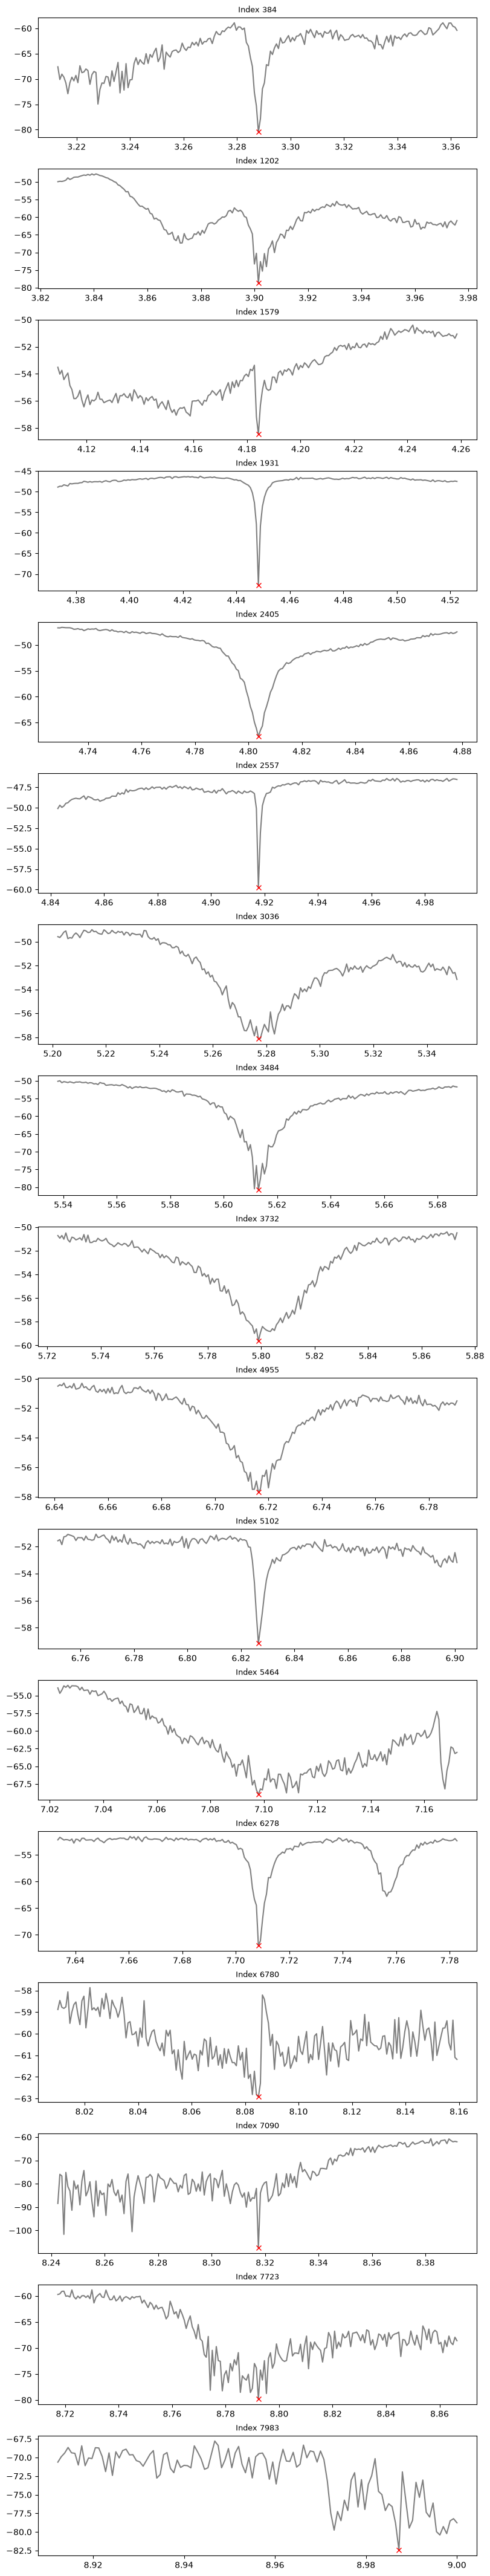

In [33]:
window = 100  # points either side of the peak

n = len(peaks_25dBm_250605_205417)  # your 28 indices

#Define Plots
fig, axs = plt.subplots(n, 1, figsize=(8, 2.5 * n), layout='constrained', squeeze=False)
axs = axs.flatten()

#Simplfy
freq = df_3_9GHz_25dBm_250605_205417['Frequency (GHz)']
mag = df_3_9GHz_25dBm_250605_205417['Magnitude (dB)']

#Loop over all peaks and plot figures
for ax, idx in zip(axs, peaks_25dBm_250605_205417):
    #Frequency Bounds of plot
    lo = max(idx - window, 0)                                #Protects from negative index
    hi = min(idx + window, len(df_3_9GHz_25dBm_250605_205417))  #Protects from out of bound indexs

    #Plot data from Ranges
    ax.plot(freq.iloc[lo:hi], mag.iloc[lo:hi], c='black', ls='-', alpha=0.5)
    ax.plot(freq.iloc[idx], mag.iloc[idx], 'x', color='red')

    #Label Figures
    ax.set_title(f'Index {idx}', fontsize=9)

plt.show()